# Minimise a function using `line_search` and `minimize` from `scipy`

In [1]:
import sys
assert sys.version_info >= (3, 7)
import numpy as np
from numpy import exp,arange
import scipy
from scipy.optimize import line_search, minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show

# Set seed for reproducibility
np.random.seed(42)

In [2]:
def objective_func(x):
    """
    Objective function to minimise, which is 
    a quadratic polynomial in three variables. 
    
    """
    
    return x[0]**2 + 2*x[1]**2 + 2*x[2]**2 + 2*x[0]*x[1] + 2*x[2]*x[1]

The function is a convex quadratic polynomial, which has a single global minimum, and this can be confirmed via data visualisation.

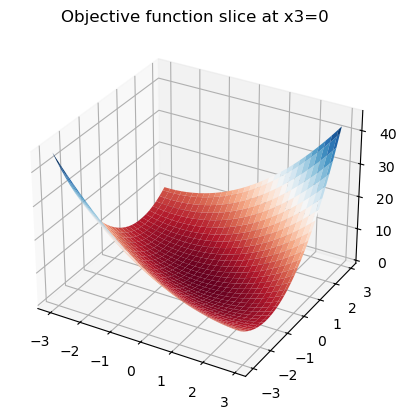

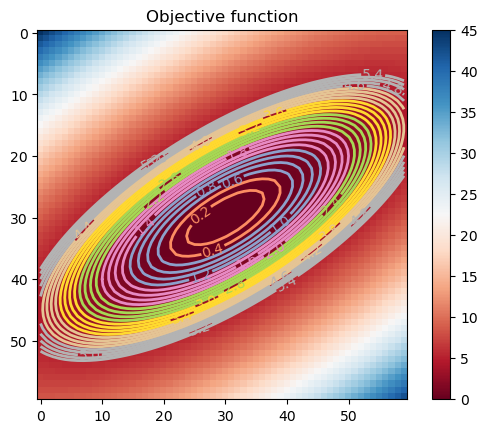

In [16]:
x1 = np.arange(-3.0, 3.0, 0.1)
x2 = np.arange(-3.0, 3.0, 0.1)
X1, X2 = np.meshgrid(x1, x2)
Z = objective_func([X1, X2, np.zeros_like(X1)])  # setting x3 to 0 for 2D slice

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Z, cmap="RdBu")
ax.set_title("Objective function slice at x3=0")
plt.show()

# Make the contour plot for extra clarity
# code taken from Kelsey (2024)
im = imshow(Z,cmap=cm.RdBu)  
cset = contour(Z,arange(-1,5.5,0.2),linewidths=2,cmap=cm.Set2)
clabel(cset,inline=True,fmt="%1.1f",fontsize=10)
colorbar(im)
title("Objective function")
show()

By looking at the plot, the 2D representation of the function looks quadratic. The 2D slice of the function suggests convexity, indicating a single global minima.

In [4]:
def objective_grad(x):
    """
    Gradient of the objective function.
    Specifically vector of partial derivatives of the objective function, 
    required for gradient-based optimisation.
    
    """
    
    return np.array([2*x[0] + 2*x[1], 4*x[1] + 2*x[0] + 2*x[2], 4*x[2] + 2*x[1]])

def objective_hessian():
    """
    Hessian of the objective function, 
    which is the matrix of second derivatives.
    
    """
    
    return np.array([[2,2,0],[2,4,2],[0,2,4]])

# The starting point could be anything, lets set 3 random points since the function has 3 dimensions
starting_point = np.random.rand(3)
starting_point_zero = np.array([0.0, 0.0, 0.0]) # alternative starting point
print("Starting point:", starting_point)

# Set a descending direction
grad_direction = -objective_grad(starting_point)
grad_direction_zero = -objective_grad(starting_point_zero)

Starting point: [0.37454012 0.95071431 0.73199394]


In [5]:
line_search(objective_func, objective_grad, starting_point, grad_direction)

(0.15399043930089185,
 3,
 1,
 0.00038252997556243427,
 5.123621471144666,
 array([-0.01858717,  0.00667515,  0.001886  ]))

In [6]:
line_search(objective_func, objective_grad, starting_point_zero, grad_direction_zero)

(1.0, 2, 1, 0.0, 0.0, array([0., 0., 0.]))

The line-search results differ across starting points, but this is not due to multiple minima. The line search minimises the function only along the single direction that was given, rather than computing a descent direction from the gradient. Using arbitrary directions leads to different points on different lines, so the final positions depend on the starting point and direction. This does not indicate multiple stationary points, and can be made more clear by using the `optimize.minimize` method from `scipy`.

In [7]:
results_BFGS = minimize(objective_func, starting_point, method="BFGS")
results_BFGS

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1819904524047979e-16
        x: [-7.180e-09  9.391e-10 -6.747e-09]
      nit: 5
      jac: [ 2.419e-09  5.705e-09  4.693e-09]
 hess_inv: [[ 1.500e+00 -1.000e+00  5.000e-01]
            [-1.000e+00  1.000e+00 -5.000e-01]
            [ 5.000e-01 -5.000e-01  5.000e-01]]
     nfev: 28
     njev: 7

In [8]:
np.allclose(results_BFGS.x, np.zeros(3))

True

In [9]:
results_BFGS_zero = minimize(objective_func, starting_point_zero, method="BFGS")
results_BFGS_zero

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0
        x: [ 0.000e+00  0.000e+00  0.000e+00]
      nit: 0
      jac: [ 1.490e-08  2.980e-08  2.980e-08]
 hess_inv: [[1 0 0]
            [0 1 0]
            [0 0 1]]
     nfev: 4
     njev: 1

In [10]:
results_Powell = minimize(objective_func, starting_point, method="Powell")
results_Powell

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.724483417540814e-35
       x: [-1.452e-18  3.739e-18  8.715e-19]
     nit: 11
   direc: [[ 2.455e-03 -4.621e-03  1.215e-03]
           [ 2.002e-02 -1.162e-02  9.759e-03]
           [ 1.307e-03  5.789e-05 -1.438e-03]]
    nfev: 364

In [11]:
np.allclose(results_Powell.x, np.zeros(3))

True

In [12]:
results_Powell_zero = minimize(objective_func, starting_point_zero, method="Powell")
results_Powell_zero

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 0.000e+00  0.000e+00  0.000e+00]
     nit: 1
   direc: [[ 1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00]]
    nfev: 22

When using minimize with BFGS or Powell, the routines converge to points like `[-7.180e-09  9.391e-10 -6.747e-09]` and `[-1.452e-18  3.739e-18  8.715e-19]` instead of exact zeros when starting away from the minimum. These values are simply floating-point roundoff effects: the solution is numerically indistinguishable from `(0, 0, 0)` and `np.allclose(result.x, np.zeros(3))` confirms that they represent the same minimiser. Starting exactly at `x0 = (0, 0, 0)` produces exact zeros because the optimiser immediately detects no descent direction. Finally, since the function is convex, it is possible to say that there is only one minimum and `x = (0, 0, 0)` is the global minimum. This can be validated via analysing the Hessian.

In [13]:
hessian = objective_hessian()
hessian

array([[2, 2, 0],
       [2, 4, 2],
       [0, 2, 4]])

In [14]:
# Let's inspect the shape of the Hessian
hessian_det = np.linalg.det(hessian)
hessian_det

7.999999999999998

In [15]:
hessian_inv = np.linalg.inv(hessian)
hessian_inv

array([[ 1.5, -1. ,  0.5],
       [-1. ,  1. , -0.5],
       [ 0.5, -0.5,  0.5]])

The Hessian is positive definite, which means the function is strictly convex. The gradient at `x = (0, 0, 0)` is zero, so this point is a stationary point; and because the Hessian is invertible, this stationary point is unique. A unique stationary point combined with strict convexity implies that `x = (0, 0, 0)` is the global minimum.

## REFERENCES
- Kelsey, T. (2024). Topic 5: Unconstrained Optimisation [Lecture Notebook]. University of St Andrews.